## <span style="color: purple;">Cyclone rainfall analysis</span>
In this Notebook you will practice evaluating a new rainfall dataset (CCAM) against other commonly used rainfall data: reanalysis (ERA5), satellite rainfall (GPM IMERG) and gauge rainfall.

Total storm rainfall, daily and hourly rainfall are available for four impactful tropical cyclones / storms:

* CHEDZA 2015
* ANA 2022
* GOMBE 2022
* FREDDY 2023

![Storm Tracks](https://github.com/helenhooker/REPRESA_Mozambique_TC_rainfall/blob/main/4_storms_tracks.png?raw=1)

The new CCAM data is available at high resolution (4 km grid size) and at ERA5 resolution (25 km grid size, labelled LR). The satellite rainfall is also available at native resolution (10 km) and at ERA5 resolution.

###  <span style="color: purple;">Learning outcomes</span>

* Compare CCAM rainfall to existing rainfall datasets both spatially and over time.
* Investigate storms, regions and time periods of interest.
* Develop data visualisation and evaluation skills in Python and Jupyter Notebooks.

<span style="color: blue;">Helen Hooker, University of Reading</span>
![LOGO](https://github.com/helenhooker/REPRESA_Mozambique_TC_rainfall/blob/main/REPRESA_logo.png?raw=1)

### <span style="color: purple;">1. Load data</span>  
#### <span style="color: purple;">1.1 Import modules</span>
Add more modules here as needed...  

In [3]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 62.2 MB/s eta 0:00:00


In [4]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import os
import sys

#### <span style="color: purple;">1.2 Import data</span>
Some example datasets will be added here, we will start with total event rainfall. Please change the paths or add more as required for your own analysis of daily or hourly rainfall.

In [9]:
# --- 1. Define the Storm Options ---

available_storms = ["FREDDY", "ANA", "CHEDZA", "GOMBE"]

# --- 2. Check Environment & Setup Data ---
if 'google.colab' in str(get_ipython()):
    print("🚀 Detected Google Colab environment. Setting up data.")
    import gdown # Library to download from Drive

    # --- GOOGLE DRIVE FILE IDs ---

    google_drive_file_ids = {
        "ANA": "1ZDu8pEgw6L53VT7-k1b-QxBhaP3S0qk3",
        "FREDDY": "1ONV4X3nDYFp7R5WUp6Nq4CrCIcl71Qe3",
        "CHEDZA": "1i35Y5Cm3ARukFovH5lwjQu88r1JSAEL_",
        "GOMBE": "1HctO0zTB8yTnS9mW5cGRajeXqV6JOBrt"
    }
    # ----------------------------------

    # A. Ask user which storm they want to analyse
    print(f"Available storms: {', '.join(available_storms)}")

    # Check if storm_name is already defined (e.g., from a previous run or user input in a different cell)
    # If not, ask the user.
    if 'storm_name' not in globals() or globals()['storm_name'] not in available_storms:
        storm_name_input = input("Enter the storm name you want to analyse (e.g., FREDDY): ").strip().upper()
    else:
        storm_name_input = globals()['storm_name'].strip().upper() # Use existing storm_name

    storm_name = storm_name_input # Update global storm_name

    if storm_name not in available_storms:
        print(f"❌ Error: '{storm_name}' is not in the list. Please re-run this cell and choose from available options.")
        sys.exit() # Stop execution if wrong name

    # B. Get the Secret File ID from the dictionary
    file_id = google_drive_file_ids.get(storm_name)

    if not file_id:
        print(f"❌ Error: File ID not found for {storm_name}. Please check the 'google_drive_file_ids' dictionary.")
        sys.exit()

    # C. Download and Unzip
    zip_name = f"{storm_name}.zip"

    # Only download if we haven't already (saves time if they re-run the cell)
    if not os.path.exists(storm_name):
        print(f"\n⬇️ Downloading {storm_name} data...")
        try:
            # Download from Google Drive using the ID
            gdown.download(id=file_id, output=zip_name, quiet=False)

            print("📦 Unzipping...")
            # Use !unzip for shell command
            get_ipython().system(f'unzip -q {zip_name}')
            print("✅ Done! Data is ready.")

            # Clean up zip to save space
            get_ipython().system(f'rm {zip_name}')
        except Exception as e:
            print(f"❌ Download failed. Please check the File ID. Error: {e}")
            sys.exit()
    else:
        print(f"✅ Data for {storm_name} is already unzipped.")

    # D. Set the Working Directory for Colab
    working_dir = "/content"

else:
    # --- Local / JASMIN Environment Setup ---
    print("💻 Detected Local/JASMIN environment.")

    # You can keep your local default here or ask for input
    # For local/JASMIN, you might hardcode FREDDY, or allow selection via input()
    storm_name = 'FREDDY' # <<< --- Default for local testing ---
    working_dir = "/home/users/hmhooker/Madagascar/cyclone_rainfall_data/" # <<< --- Adjust this for your local setup ---
    print(f"Using local path: {working_dir}")

print(f"\n🌍 Setup Complete. Analyzing storm: {storm_name}")
print(f"📂 Working Directory: {working_dir}")


🚀 Detected Google Colab environment. Setting up data.
Available storms: FREDDY, ANA, CHEDZA, GOMBE
Enter the storm name you want to analyse (e.g., FREDDY): FREDDY

⬇️ Downloading FREDDY data...


Downloading...
From (original): https://drive.google.com/uc?id=1ONV4X3nDYFp7R5WUp6Nq4CrCIcl71Qe3
From (redirected): https://drive.google.com/uc?id=1ONV4X3nDYFp7R5WUp6Nq4CrCIcl71Qe3&confirm=t&uuid=d3a3e089-6637-4063-b9db-cde189c9f9d1
To: /content/FREDDY.zip
100%|██████████| 140M/140M [00:02<00:00, 60.7MB/s]


📦 Unzipping...
✅ Done! Data is ready.

🌍 Setup Complete. Analyzing storm: FREDDY
📂 Working Directory: /content


#### <span style="color: blue;">Choose a storm!</span>

In [10]:
# The variables 'storm_name' and 'working_dir' are already set by the cell above!

print(f"Importing data for {storm_name}...")

# Import data

CCAM = xr.open_dataset(f'{working_dir}/{storm_name}/CCAM_rainfall/CCAM_TOTAL_{storm_name}.nc')

CCAM_LR = xr.open_dataset(f'{working_dir}/{storm_name}/CCAM_rainfall/CCAM_LR_TOTAL_{storm_name}.nc')

ERA5 = xr.open_dataset(f'{working_dir}/{storm_name}/ERA5_rainfall/ERA5_TOTAL_{storm_name}.nc')

IMERG = xr.open_dataset(f'{working_dir}/{storm_name}/IMERG_rainfall/GPM_TOTAL_{storm_name}.nc')

# Complete the path

#IMERG_LR = xr...

gauge_data = pd.read_csv(f'{working_dir}/{storm_name}/{storm_name}_gauge.csv')

Importing data for FREDDY...


### <span style="color: purple;">2. Inspect the data</span>
#### <span style="color: purple;">2.1 Check the datasets</span>

In [11]:
# Change to inspect dataset of choice

#CCAM
#CCAM_LR
ERA5
#IMERG
#IMERG_LR
#gauge_data

<xarray.Dataset> Size: 61kB
Dimensions:    (latitude: 121, longitude: 121)
Coordinates:
  * latitude   (latitude) float64 968B -5.0 -5.25 -5.5 ... -34.5 -34.75 -35.0
  * longitude  (longitude) float64 968B 28.0 28.25 28.5 ... 57.5 57.75 58.0
    number     int64 8B ...
Data variables:
    tp         (latitude, longitude) float32 59kB ...

#### <span style="color: purple;">2.2 Extract variables and crop data</span>

You may notice that the IMERG data is transposed compared to the other datasets, so we correct this here (remember to also correct the IMERG_LR too!)

In [12]:
IMERG['precipitation'] = IMERG['precipitation'].transpose('lat', 'lon')

# Complete for IMERG_LR

#IMERG_LR...

#### <span style="color: blue;">Choose a region of your interest</span>

In [13]:
lat_range = slice(-35, -5.0)
lon_range = slice(28, 58)

# Crop the rainfall data and pre-process so that all are in mm
CCAM_rainfall = CCAM['rnd'].sel(lat = lat_range, lon = lon_range) / 24 # convert mm/day to mm/h

#CCAM_LR_rainfall =
CCAM_LR_rainfall = CCAM_LR['rnd_LR'].sel(latitude = lat_range, longitude = lon_range) / 24

ERA5_rainfall = ERA5['tp'].where((ERA5['latitude'] >= lat_range.start) & (ERA5['latitude'] <= lat_range.stop) &
                                     (ERA5['longitude'] >= lon_range.start) & (ERA5['longitude'] <= lon_range.stop),
                                     drop=True) * 1000 # convert m to mm

IMERG_rainfall = IMERG['precipitation'].sel(lat = lat_range, lon = lon_range)

# Complete...
#IMERG_LR_rainfall =

Check that the max and min rainfalls are realistic.

In [14]:
CCAM_rainfall.max()

<xarray.DataArray 'rnd' ()> Size: 8B
array(1863.24865723)

### <span style="color: purple;">3. Plot the data</span>
#### <span style="color: purple;">2.1 Quick basic plots</span>
A quick plot can be a good sense check of the data, change the code to visualise the other datasets.

Change the storm name and have a quick look at another storm too.

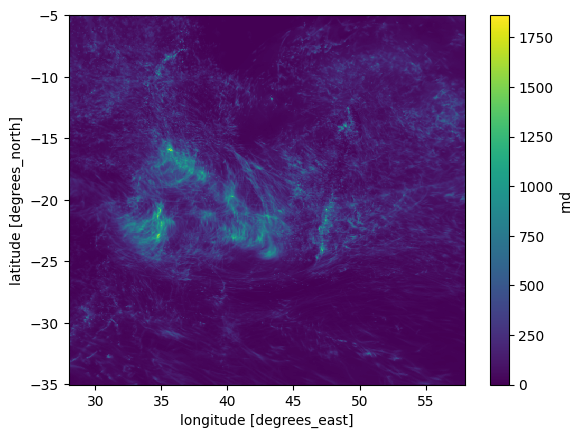

In [15]:
CCAM_rainfall.plot()

#### <span style="color: purple;">2.2 Plot the rain gauge data</span>
Try to amend the gauge rainfall plotted to show daily rainfall for an interesting day and for a different storm.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


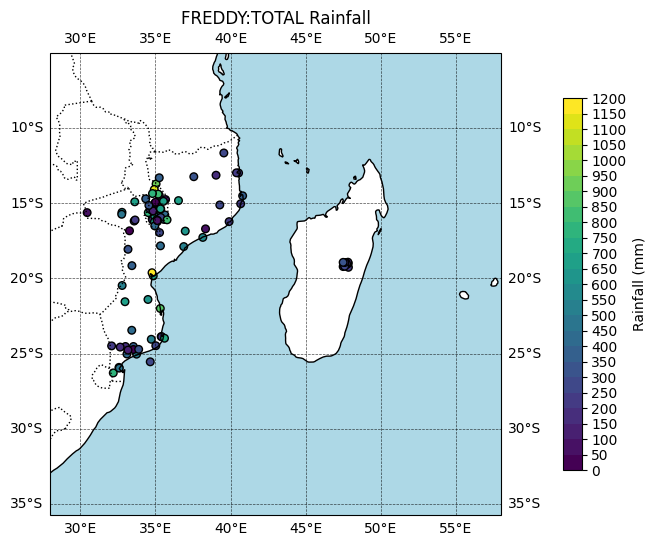

In [16]:
# Filter the data for the specific date of interest format e.g. 13/03/2023

date_of_interest = 'TOTAL'

# Define longitude and latitude ranges
lat_range = slice(-5, -35)
lon_range = slice(28, 58)

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_range.start, lon_range.stop, lat_range.start, lat_range.stop])

# Add country borders
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1, edgecolor='black')

# Add coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')

# Set the face color of the ocean to light blue
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Add latitude and longitude gridlines
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5, color='black', alpha=0.7)

gauge_rainfall = gauge_data[['STATION', 'LONGIT', 'LATIT', date_of_interest]]

gauge_rainfall.loc[:, date_of_interest] = pd.to_numeric(gauge_rainfall[date_of_interest], errors='coerce')

# Drop rows with missing latitude or longitude values
gauge_rainfall = gauge_rainfall.dropna(subset=['LONGIT', 'LATIT'])

# Define discrete intervals for the color scale
boundaries = np.arange(0, gauge_rainfall[date_of_interest].max() + 50, 50)  # 0 to max + 50 in steps of 50
norm = BoundaryNorm(boundaries, ncolors=256, clip=True)

# Plot each point on the map with normalized colors
scatter = ax.scatter(
    gauge_rainfall['LONGIT'],
    gauge_rainfall['LATIT'],
    c=gauge_rainfall[date_of_interest],
    cmap='viridis',
    norm=norm,
    edgecolors='black',
    s=30,
    transform=ccrs.PlateCarree()
)

# Add colorbar with discrete intervals
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.03, pad=0.1)
cbar.set_label('Rainfall (mm)')
cbar.set_ticks(boundaries)  # Set the ticks to match the discrete intervals
cbar.update_ticks()  # Refresh the ticks

# Set title
title = f'{storm_name}:{date_of_interest} Rainfall'
ax.set_title(title)

# Show the plot
plt.show()

#### <span style="color: purple;">2.3 Plot the spatial data</span>
Here you will plot three datasets together to compare.

Change CCAM and IMERG to CCAM_LR and IMERG_LR, what do you notice?

Can you improve and create a custom colorbar?

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


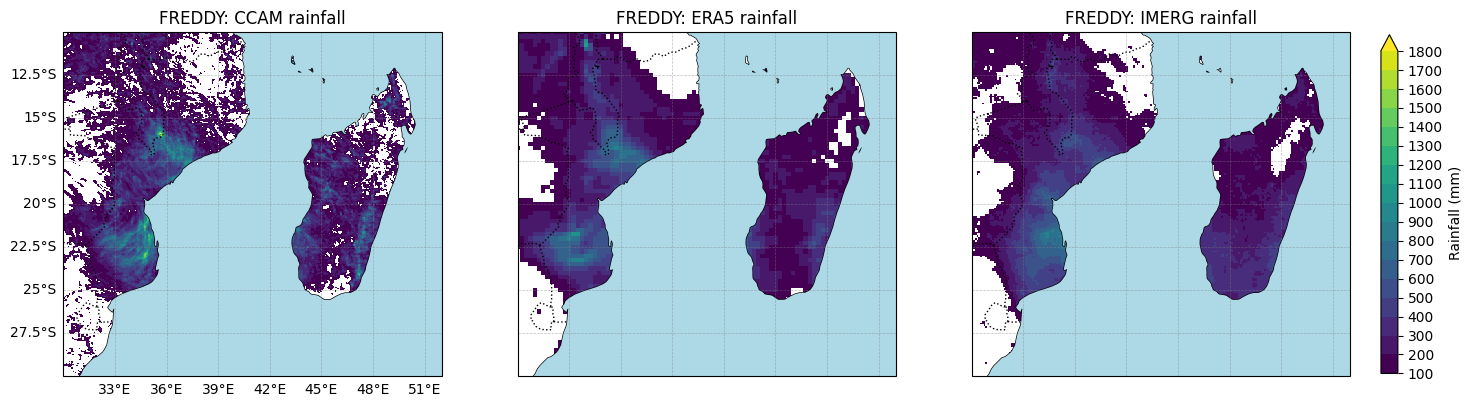

In [17]:
# Find the overall maximum value across the datasets
max_value = max(CCAM_rainfall.max().values, ERA5_rainfall.max().values, IMERG_rainfall.max().values)

# Define rounded discrete levels for the color bar
levels = np.arange(100, max_value + 1, 100)

# Create a figure with subplots for side-by-side comparison
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add features and grid lines
for index, ax in enumerate(axes):
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.set_extent([30, 52, -30, -10])  # Adjust based on your area of interest

    # Configure gridlines
    gl = ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--', zorder=3)
    gl.right_labels = False  # Disable right labels for all plots
    if index == 0:
        gl.left_labels = True   # Enable left labels only for the first axis (left plot)
        gl.bottom_labels = True

# Plot CCAM
ccam_plot = CCAM_rainfall.fillna(0).where(CCAM_rainfall > 100).plot(ax=axes[0], cmap='viridis', levels=levels, add_colorbar=False)
axes[0].set_title(f'{storm_name}: CCAM rainfall')
#axes[0].set_xlabel('Longitude')
#axes[0].set_ylabel('Latitude')

# Plot ERA5
era5_plot = ERA5_rainfall.fillna(0).where(ERA5_rainfall > 100).plot(ax=axes[1], cmap='viridis', levels=levels, add_colorbar=False)
axes[1].set_title(f'{storm_name}: ERA5 rainfall')


# Plot IMERG
imerg_plot = IMERG_rainfall.fillna(0).where(IMERG_rainfall > 100).plot(ax=axes[2], cmap='viridis', levels=levels, add_colorbar=False)
axes[2].set_title(f'{storm_name}: IMERG rainfall')

# Add a single colorbar for all three plots
cbar = plt.colorbar(ccam_plot, ax=axes, orientation='vertical', pad=0.02, aspect=20, shrink=0.55)
cbar.set_label('Rainfall (mm)')
cbar.set_ticks(levels)

plt.show()

#### <span style="color: purple;">2.4 Compare gauge rainfall with spatial datasets</span>
Here you will extract the rainfall from the corresponding grid cell to each rain gauge and plot these on a scatter plot along with skill scores mean absolute error (MAE), root mean squared error (RMSE) and Pearson correlation coefficient (PCC). Try this for different datasets and storms.

What are the differences or similarities between the datasets and storms, can you explain why?

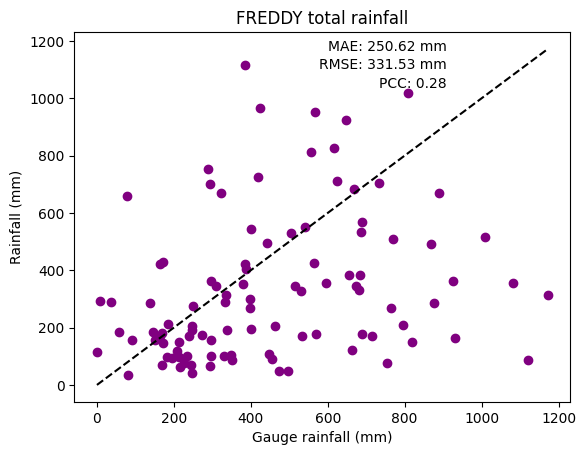

In [18]:
# Change the rainfall dataset
rainfall_dataset = CCAM_rainfall

dataset_rainfall = []
for i, row in gauge_rainfall.iterrows():
    lat, lon = row['LATIT'], row['LONGIT']
    dataset_rainfall.append(rainfall_dataset.sel(lat=lat, lon=lon, method='nearest').item())

# Create a scatter plot to compare observed and modeled precipitation
fig, ax = plt.subplots()
ax.scatter(gauge_rainfall[date_of_interest], dataset_rainfall, color='purple')
ax.plot([0, gauge_rainfall[date_of_interest].max()], [0, gauge_rainfall[date_of_interest].max()], color='black', linestyle='--', label='1:1 Line')
ax.set_xlabel('Gauge rainfall (mm)')
ax.set_ylabel('Rainfall (mm)')
ax.set_title(f'{storm_name} total rainfall')

gauge_values = np.array(gauge_rainfall[date_of_interest])
dataset_values = np.array(dataset_rainfall)

# Calculate MAE and RMSE
mae_value = np.mean(np.abs(gauge_values - dataset_values))
rmse_value = np.sqrt(np.mean((gauge_values - dataset_values) ** 2))
corr_coef = np.corrcoef(gauge_values, dataset_values)[0, 1]

# Define units
units = 'mm'

# Add MAE and RMSE with units to the plot
ax.annotate(f'MAE: {mae_value:.2f} {units}', xy=(0.75, 0.95), xycoords='axes fraction', ha='right', fontsize=10, color='black')
ax.annotate(f'RMSE: {rmse_value:.2f} {units}', xy=(0.75, 0.9), xycoords='axes fraction', ha='right', fontsize=10, color='black')
ax.annotate(f'PCC: {corr_coef:.2f}', xy=(0.75, 0.85), xycoords='axes fraction', ha='right', fontsize=10, color='black')

plt.show()

#### <span style="color: purple;">2.5 Calculate the spatial difference</span>
Here you can choose which datasets to compare by calculating the difference in rainfall. To calculate the spatial difference, the datasets must be at the same horizontal resolution (grid size) so you will need to use CCAM_LR_rainfall and IMERG_LR_rainfall to compare all three datasets.

Where are the main differences? Why are the differences in particular locations?

In [19]:
# Calculate the rainfall difference between two datasets
rainfall_difference = CCAM_LR_rainfall - ERA5_rainfall
rainfall_difference.max()

<xarray.DataArray ()> Size: 8B
array(903.71777344)
Coordinates:
    number   int64 8B 0

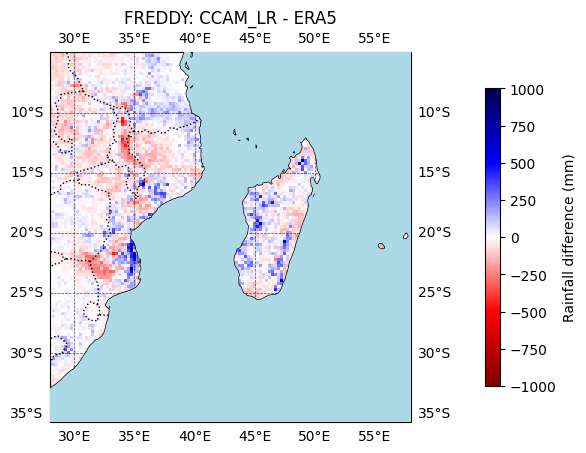

In [20]:
# Create a plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_range.start, lon_range.stop, lat_range.start, lat_range.stop])

# Add country borders
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1, edgecolor='black')

# Add coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')

ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder = 10)

# Plot rainfall difference data
pcm = rainfall_difference.fillna(0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='seismic_r', add_colorbar=False, vmin=-1000, vmax=1000)

# Add latitude and longitude gridlines
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5, color='black', alpha=0.7)

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', fraction=0.03, pad=0.15)
cbar.set_label('Rainfall difference (mm)')

# Customize plot
ax.set_title(f'{storm_name}: CCAM_LR - ERA5')

# Show the plot
plt.show()

### <span style="color: purple;">3. Your own analysis</span>  
What else would you like to discover? Continue investigating the data here with what you have learned so far and by developing your own code. Feel free to use AI tools such as ChatGPT to help you!

Can you plot daily or hourly rainfall data on a map for selected days or hours for different storms and datasets?

Can you plot a daily or hourly timeseries of rainfall (hyetographs) for a chosen location (grid cell, area or sub-catchment) and time period for one or more datasets to compare?

Can you compare the distribution of total, daily and hourly rainfall across each dataset? How do the rainfall extremes compare?